In [1]:
# Dudh Dairy Sales Analysis - Initial Exploration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This makes your plots appear inside the notebook
%matplotlib inline

# Optional: This makes your plots look a bit nicer
sns.set_style('whitegrid')

In [3]:
customers_df = pd.read_csv('customers.csv')
products_df = pd.read_csv('products.csv')
orders_df = pd.read_csv('orders.csv')

In [4]:
# See the first 5 rows
print("First 5 rows of orders:")
orders_df.head()

First 5 rows of orders:


,order_id,customer_id,product_id,order_date,quantity
0,5001,1491,214,2026-05-18,3
1,5002,1088,202,2025-03-11,1
2,5003,1083,211,2026-05-12,2
3,5004,1011,213,2026-05-26,5
4,5005,1015,215,2025-10-14,1


In [5]:
# Get a summary of the orders dataframe
print("Information about orders:")
orders_df.info()

Information about orders:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   order_id     1500 non-null   int64
 1   customer_id  1500 non-null   int64
 2   product_id   1500 non-null   int64
 3   order_date   1500 non-null   str  
 4   quantity     1500 non-null   int64
dtypes: int64(4), str(1)
memory usage: 58.7 KB


In [6]:
# Let's combine orders with product details
# We merge on the column they have in common: 'product_id'
merged_df = pd.merge(orders_df, products_df, on='product_id')

# Let's check the result!
merged_df.head()

,order_id,customer_id,product_id,order_date,quantity,name,category,price
0,5001,1491,214,2026-05-18,3,Chocolate Milk (200ml),Drinks,35
1,5002,1088,202,2025-03-11,1,Full Cream Milk (1L),Milk,60
2,5003,1083,211,2026-05-12,2,Skimmed Milk (1L),Milk,55
3,5004,1011,213,2026-05-26,5,Probiotic Yogurt (150g),Curd & Yogurt,45
4,5005,1015,215,2025-10-14,1,Cheese Block (200g),Value-Add,150


In [7]:
# Count how many times each product name appears in the orders
top_products = merged_df['name'].value_counts().head(10) # Get the top 10

print("Top 10 Most Frequently Sold Products:")
print(top_products)

Top 10 Most Frequently Sold Products:
name
Paneer Cubes (200g)        94
Curd (400g)                87
Dahi with Fruit (500g)     87
Toned Milk (500ml)         82
Chocolate Milk (200ml)     80
Skimmed Milk (1L)          77
Cheese Slices (10 pack)    77
Ghee (500g)                76
Full Cream Milk (1L)       75
Cheese Block (200g)        75
Name: count, dtype: int64


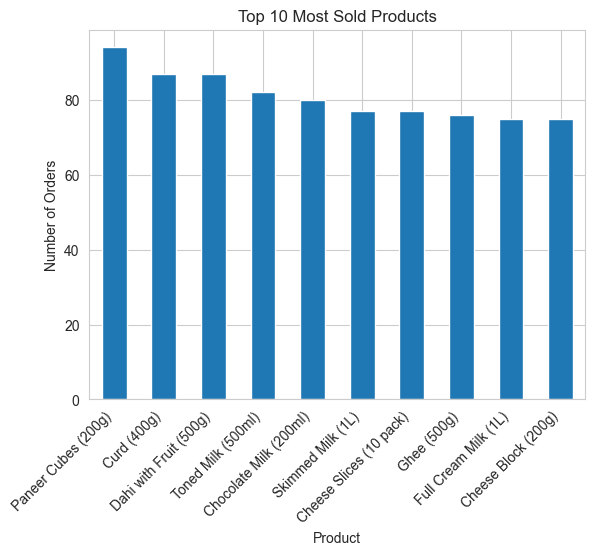

In [8]:
top_products.plot(kind='bar')

plt.title('Top 10 Most Sold Products')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right') # Rotates the x-axis labels to be readable
plt.show()

In [9]:
# Let's combine orders with product details
# We merge on the column they have in common: 'product_id'
merged_df = pd.merge(orders_df, products_df, on='product_id')

# Let's check the result!
merged_df.head()

,order_id,customer_id,product_id,order_date,quantity,name,category,price
0,5001,1491,214,2026-05-18,3,Chocolate Milk (200ml),Drinks,35
1,5002,1088,202,2025-03-11,1,Full Cream Milk (1L),Milk,60
2,5003,1083,211,2026-05-12,2,Skimmed Milk (1L),Milk,55
3,5004,1011,213,2026-05-26,5,Probiotic Yogurt (150g),Curd & Yogurt,45
4,5005,1015,215,2025-10-14,1,Cheese Block (200g),Value-Add,150


In [10]:
## Time-Series Analysis: Monthly Revenue Trends

In [11]:
# Create a new 'revenue' column
merged_df['revenue'] = merged_df['quantity'] * merged_df['price']

# Check to make sure it worked
merged_df.head()

,order_id,customer_id,product_id,order_date,quantity,name,category,price,revenue
0,5001,1491,214,2026-05-18,3,Chocolate Milk (200ml),Drinks,35,105
1,5002,1088,202,2025-03-11,1,Full Cream Milk (1L),Milk,60,60
2,5003,1083,211,2026-05-12,2,Skimmed Milk (1L),Milk,55,110
3,5004,1011,213,2026-05-26,5,Probiotic Yogurt (150g),Curd & Yogurt,45,225
4,5005,1015,215,2025-10-14,1,Cheese Block (200g),Value-Add,150,150


In [12]:
# Convert the 'order_date' column to datetime objects
merged_df['order_date'] = pd.to_datetime(merged_df['order_date'])

# Check the data type to confirm
merged_df.info() # Look for 'order_date' and see that it's now 'datetime64[ns]'

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     1500 non-null   int64         
 1   customer_id  1500 non-null   int64         
 2   product_id   1500 non-null   int64         
 3   order_date   1500 non-null   datetime64[us]
 4   quantity     1500 non-null   int64         
 5   name         1500 non-null   str           
 6   category     1500 non-null   str           
 7   price        1500 non-null   int64         
 8   revenue      1500 non-null   int64         
dtypes: datetime64[us](1), int64(6), str(2)
memory usage: 105.6 KB


In [13]:
# Set the 'order_date' as the index of our dataframe, which is best practice for time series
monthly_revenue = merged_df.set_index('order_date')['revenue'].resample('ME').sum()

print("Total Revenue Per Month:")
print(monthly_revenue)

Total Revenue Per Month:
order_date
2024-06-30      225
2024-07-31      520
2024-08-31      780
2024-09-30     1905
2024-10-31     1320
2024-11-30     5690
2024-12-31     6050
2025-01-31     3455
2025-02-28     4140
2025-03-31     5135
2025-04-30     6550
2025-05-31     8915
2025-06-30    12670
2025-07-31    12850
2025-08-31    12245
2025-09-30    21190
2025-10-31    14550
2025-11-30    15515
2025-12-31    22440
2026-01-31    21390
2026-02-28    21570
2026-03-31    36310
2026-04-30    44890
2026-05-31    64770
2026-06-30    12810
Freq: ME, Name: revenue, dtype: int64


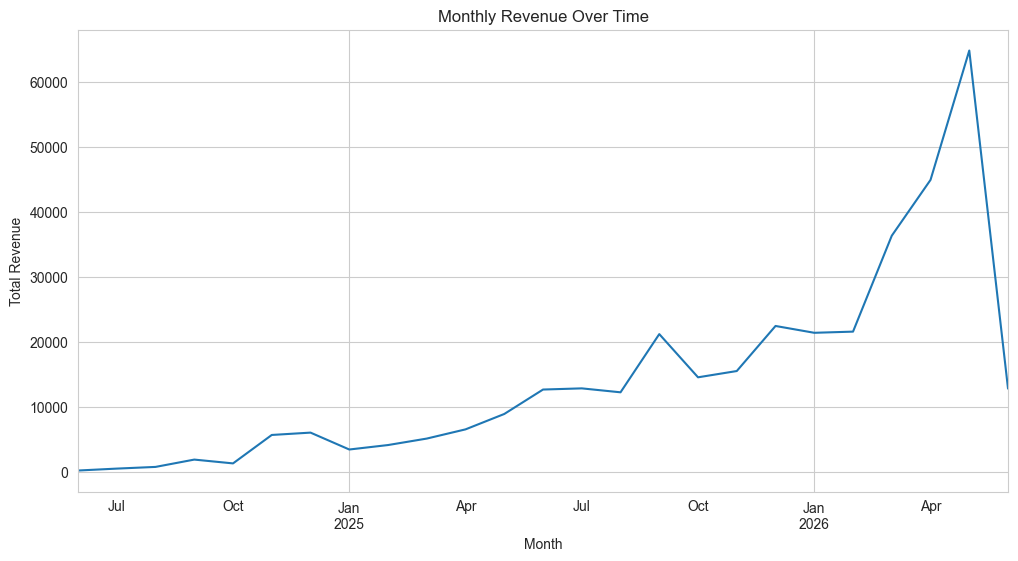

In [14]:
monthly_revenue.plot(kind='line', figsize=(12, 6)) # figsize makes the plot wider

plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

In [15]:
## Customer Analysis: Identifying Top 10 Customers by Revenue

In [18]:
# First, we need to merge our main dataframe with the customer data to get their names
full_df = pd.merge(merged_df, customers_df, on='customer_id')

# Now, group by customer name and sum the revenue
top_customers = full_df.groupby('name_y')['revenue'].sum().sort_values(ascending=False).head(10)

print("Top 10 Customers by Total Revenue:")
print(top_customers)

Top 10 Customers by Total Revenue:
name_y
Anay Chand             3705
Pahal Balakrishnan     3350
Lucky Parmar           3170
Owen Wable             3070
George Mangat          2920
Jagat Krishnamurthy    2855
Aarnav Desai           2820
Ayush Uppal            2670
Inaya Sandal           2595
Bina Varghese          2500
Name: revenue, dtype: int64


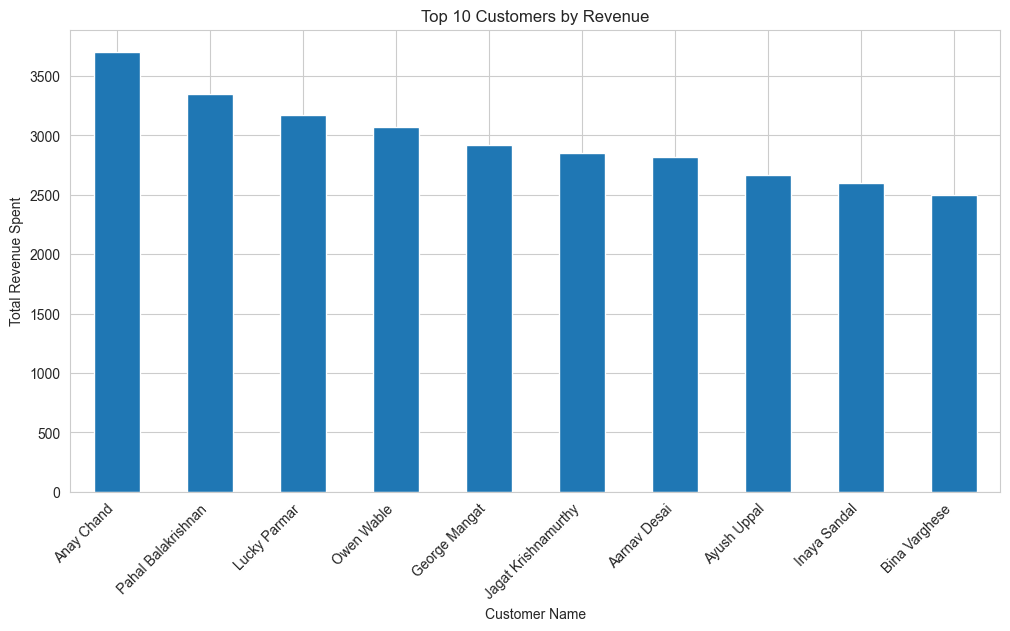

In [19]:
top_customers.plot(kind='bar', figsize=(12, 6))

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer Name')
plt.ylabel('Total Revenue Spent')
plt.xticks(rotation=45, ha='right')
plt.show()